# Seminars 11&12

## Classification

Classification $y_i \in \{1, ... , K\}$- $K$ classes

Example of multiclass ($K \ge 3$) classification task:


*   Classify images (what is on the picture?)


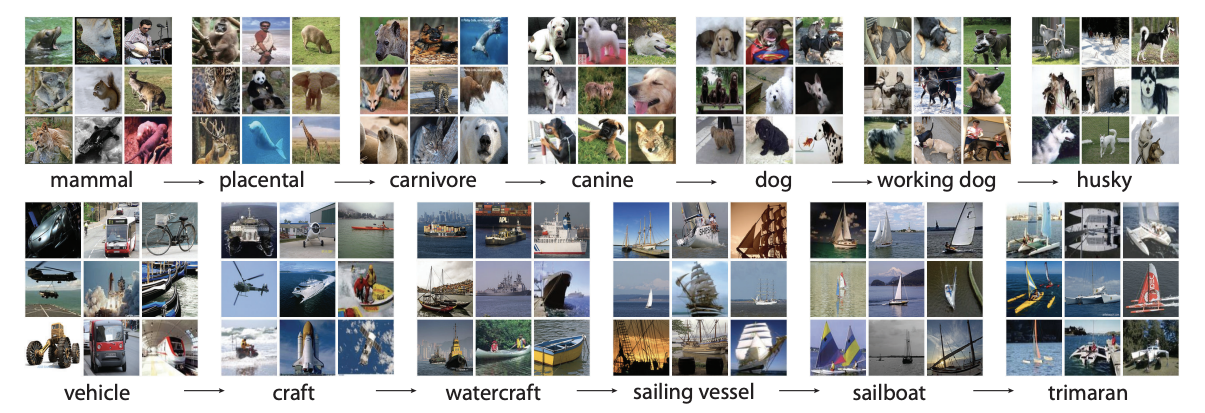

*   Classify texts by topic (travel, comedy, business, ...)
*   [Air quality of the region](https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment) (good/ok/bad/hazardous?)
*   [Stress level](https://www.kaggle.com/datasets/poushal02/student-academic-stress-real-world-dataset) (no sress/some stress/a lot of stress)


Binary classification - 2 classes (often $y_i \in \{ -1, +1\}$ or $y_i \in \{ 0, +1\}$)

Examples:


*   [Does post contain mention of a disaster?](https://www.kaggle.com/datasets/vstepanenko/disaster-tweets)
* [Does the student have depression?](https://www.kaggle.com/datasets/hopesb/student-depression-dataset)
*  [Are news fake?](https://www.kaggle.com/datasets/evilspirit05/bengali-fake-news-dataset)


## Logistic regression

### Theory

 We'll solve the binary classification problem by predicting the probability that an object belongs to the positive (+1) class.

 Suppose we have a linear model of the form:

 $$a(x) = w_0 + w_1x_1 + w_2x_2 + ... + w_d x_d = w_0 + \sum_{i=1}^d w_ix_i$$



**Question:** can we use $a(x)$ as a probability of a positive class?

To get  probability we use sigmoid or logistic function.

$$\sigma(x)=\frac{1}{1+e^{−x}}$$

It looks like this:

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/Logistic-curve.svg/1200px-Logistic-curve.svg.png" width="500" height="300">

And knowing the probabilities ($p=\sigma(a(x))$), we will ultimately be able to say whether the object belongs to class 0 or +1.

For example, we can consider that if the probability of belonging to the positive class is greater than 0.5 ($p>0.5$), the object is classified as positive class (+1), otherwise, negative class (0).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Practise

Let's use [Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set)

This dataset consists of 150 observations, each of which represents four measurements: `sepal length`, `sepal width`, `petal length`, and `petal width`. Each observation belongs to one of three iris classes: setosa, versicolor, or virginica.

The task is to predict the flower class based on the measurements.

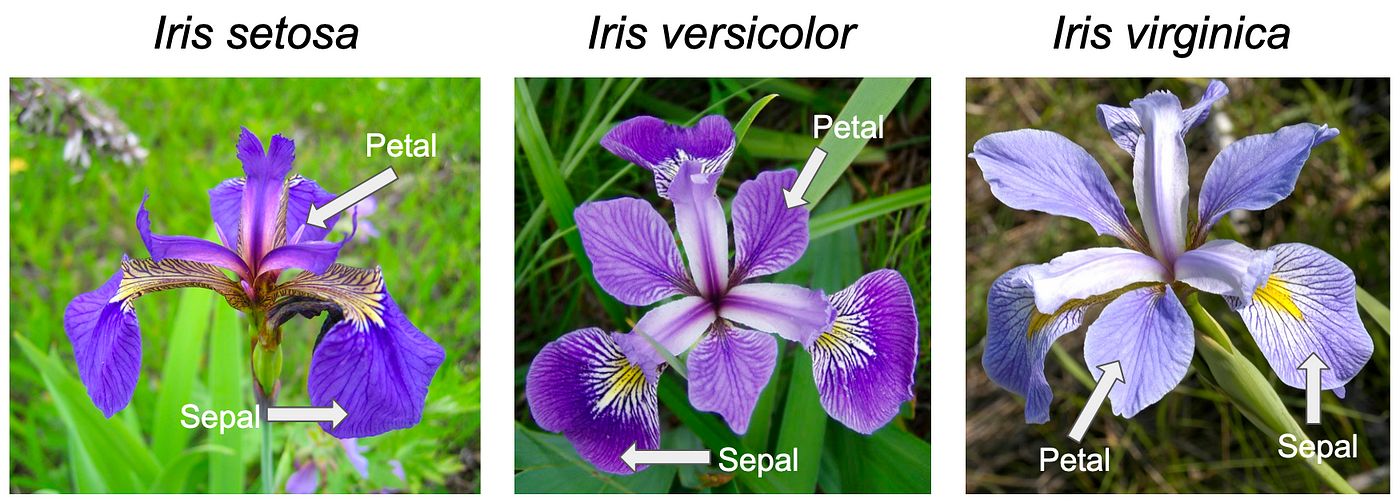

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target'].copy()
X.head()

In [ ]:
np.unique(y, return_counts=True)

In [ ]:
data['target_names']

Let's make the classification binary: we will predict if the flower is versicolor or not.

So versicolor (class 1) will be +1 and setosa, virginica (classes 0, 2) will be 0.

**Task** Change the target vector `y`

In [ ]:
#your code here

In [ ]:
assert np.allclose(np.unique(y, return_counts=True), (np.array([0, 1]), np.array([100,  50])))

np.unique(y, return_counts=True)

Also, let's work only with 2 features (so it would be possible to plot)

**Task** choose the features`sepal length (cm)` and `sepal width (cm)`

In [ ]:
X = #your code here

Let's split the data into train and test sets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

In [ ]:
np.unique(y_train, return_counts=True)

In [ ]:
np.unique(y_test, return_counts=True)

In [ ]:
y_test

In [ ]:
plt.title('Train points colored by target')

#color is the target: purple (0) and yellow (1)
plt.scatter(X_train['sepal length (cm)'],
            X_train['sepal width (cm)'],
            c = y_train);

Note: selecting train/test randomly is important. Why? - order of the samples will not break our pipeline:

What if we just decided to take the last 30\% of samples as test?

In [ ]:
##THIS IS BAD CODE, DO NOT USE IT FOR TRAIN-TEST SELECTION##
X_train_bad = X[:-int(len(X) * 0.3)]
X_test_bad = X[-int(len(X) * 0.3):]
y_train_bad = y[:-int(len(X) * 0.3)]
y_test_bad = y[-int(len(X) * 0.3):]

In [ ]:
y_test_bad

In [ ]:
y_test



Split data in train and test carefully!

Let's fit logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

Now, we can predict:

In [ ]:
lr.predict(X_train)

In [ ]:
plt.title('Train points colored by prediction of the model')
#color is the prediction: purple (0) and yellow (1)
plt.scatter(X_train['sepal length (cm)'],
            X_train['sepal width (cm)'],
            c = lr.predict(X_train))

It is possible to get the probabilities:

In [ ]:
lr.predict_proba(X_train)[:10]

We also can see the coefficients and intercept:

In [ ]:
lr.intercept_, lr.coef_

Let's try to apply manually:

For example, we have a sample with `sepal length (cm)` = 6, `sepal width (cm)` = 3

In [ ]:
w_0 = lr.intercept_[0]
w_1, w_2 = lr.coef_[0]

Compute $a(x) = w_0 + w_1x_1 + w_2x_2$, where $x_1$ - sepal length (cm) $x_2$ - sepal width (cm)

In [ ]:
a = w_0 + w_1 * 6 + w_2 * 3
a

In [ ]:
#this value can be computed using sklearn
lr.decision_function([[6.0, 3.0]])

Now, apply the $\sigma$, to get the probability $p$ of class 1:

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

p = sigmoid(a)
p

And the probability of class 0 is $1 - p$

In [ ]:
1 - p

The same using sklearn: first column - the probability of class 0, second - probability of class 1.

In [ ]:
lr.predict_proba([[6.0, 3.0]])

And the final prediction is 1 if $p > 0.5$ and 0 otherwise

In [ ]:
int(p > 0.5)

Using sklearn:

In [ ]:
lr.predict([[6.0, 3.0]])

In the end, the sample should be classified as class 0 (the probability of it being class 0 is estimated as around 0.7)

### Plotting

Let's visualize the model. But how?

In linear regression $y = w_0 + w_1 x_1 + w_2 x_2$ (if there are 2 features)

In logistic regression $y = \sigma(w_0 + w_1 x_1 + w_2 x_2) = \frac{1}{e^{-(w_0 + w_1 x_1 + w_2 x_2)}}$

That seems hard, however to visualize the model we do not need to work with $\sigma()$. Why? - Because $\sigma()$ just gives the probability.

If $x>0 \Rightarrow \sigma(x) > 0.5$ - class 1

If $x=0 \Rightarrow \sigma(x) = 0.5$ - unsure

If $x<0 \Rightarrow \sigma(x) < 0.5$ - class 0

So, if we draw the points, where model is unsure - we will draw the curve that separates the classes (if the point is not on the curve - the class is known)

So, we need to solve $w_0 + w_1 x_1 + w_2 x_2 = 0$

Answer:

$x_2 = -\frac{w_0 + w_1 x_1}{w_2}$

This is a straight line.


In [ ]:
#generate x1
x_1 = np.arange(X_train['sepal length (cm)'].min(), X_train['sepal length (cm)'].max()+0.2, 0.05)
#calculate x2
x_2 = -(w_0 + x_1 * w_1) / w_2

In [ ]:
plt.plot(x_1, x_2);

Adding train/tet data

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 6))
axs[0].set_title('Train points colored by target and model')
axs[1].set_title('Train points colored by prediction and model')

axs[0].scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c = y_train)
axs[1].scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c = lr.predict(X_train))

axs[0].plot(x_1, x_2)
axs[1].plot(x_1, x_2)

And for the test set:

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 6))
axs[0].set_title('Test points colored by target and model')
axs[1].set_title('Test points colored by prediction and model')

axs[0].scatter(X_test['sepal length (cm)'], X_test['sepal width (cm)'], c = y_test)
axs[1].scatter(X_test['sepal length (cm)'], X_test['sepal width (cm)'], c = lr.predict(X_test))

axs[0].plot(x_1, x_2)
axs[1].plot(x_1, x_2)

Actually, for easier plotting we can use special function:

In [ ]:
#!pip install mlxtend

In [ ]:
from mlxtend.plotting import plot_decision_regions

In [ ]:
#Train
plot_decision_regions(X_train.values,
                      y_train,
                      clf=lr)

In [ ]:
#Test
plot_decision_regions(X_test.values,
                      y_test,
                      clf=lr)

### Hyperparameters

We also have hyperparameters for logistic regression.

For example, we also can apply regularization and we have $\alpha$ - the strength of it.

However! In sklearn [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html) there is no `alpha`, but there is 'C': inverse of regularization strength ($C = \frac{1}{\alpha}$). So the smaller C, the stronger is the regularization.


In [ ]:
C_list = [0.1, 0.5, 10]

fig, axs = plt.subplots(ncols=3, figsize=(12, 8))

for ii, C in enumerate(C_list):
    clf = LogisticRegression(C=C)
    clf.fit(X_train.values, y_train)


    plot_decision_regions(X_train.values, y_train, clf=clf, legend=2, ax=axs[ii])
    axs[ii].set_title('C='+str(C))

We can see that the model differ if we change C.

We need to tune it. Same approaches (validation set, cross-validation) can be used

To assess the model (and to search for hyperparameters) we need to use the quality metrics

## Quality metrics (for beginners)

Error rate:

$$\frac{1}{N} \sum_{i=1}^N I[y_i \neq \hat{y}_i]$$

From 0 to 1, closer to 0 - better

Accuracy:

$$\frac{1}{N} \sum_{i=1}^N I[y_i = \hat{y}_i]$$


From 0 to 1, closer to 1 - better

In [ ]:
from sklearn.metrics import accuracy_score


print('Train accuracy =', accuracy_score(y_train, lr.predict(X_train)))
print('Test  accuracy =', accuracy_score(y_test,  lr.predict(X_test)))

What san be said: on the new data our model classify 64\% of samples correctly

**Question** what will be the accuracy of random classifier? (with probability 0.5 gives class 0 and with probability 0.5 gives class 1)

**Task** Create a random classifier and compute the accuracy

In [ ]:
#your code here

**Question** if we do not want to use our features at all, how can we make a best possible prediction?

**Task** create such predicitons and compute acuracy

In [ ]:
#your code here

## Hyperparameter tuning using cross-validation

We need to search for best hyperparameter $C$, we can divide into train, validation and test.


Problem with separate validation set: shrink the amount data to use for training.

Idea: let's split the data into $n$ folds of similar size and train the model $n$ times, each time - one fold is validation and other $n-1$ is trin set. Compute loss $n$ times and take average.

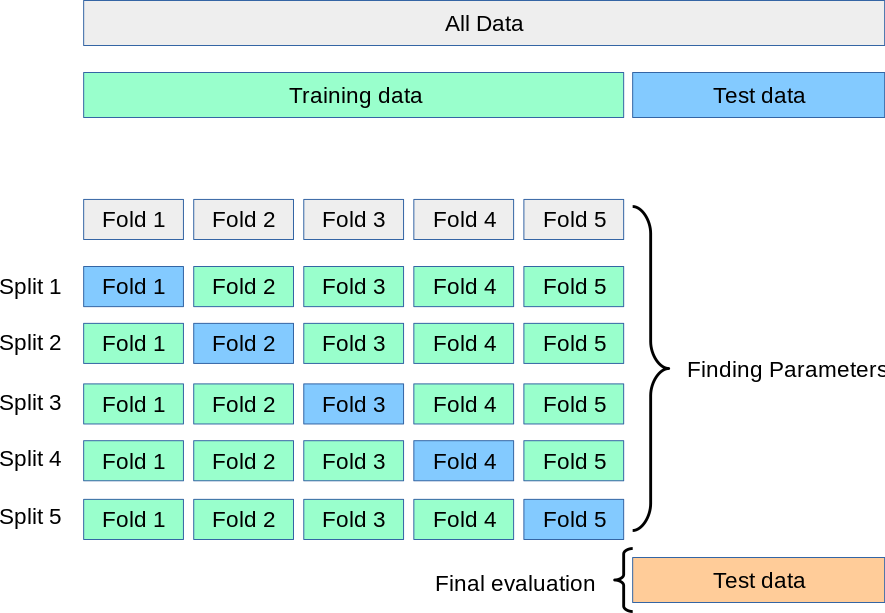

Cross-validation is useful for hyperparameter search: for every set of hyperparameters apply cross-validation and compute the quality. Choose the model with the best quality

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'C' : np.logspace(-5, 2, 100)
         }

clf = GridSearchCV(LogisticRegression(), params,
                   cv=5, scoring='accuracy',
                   verbose=5 #how much info we want to see
                   )
clf.fit(X_train, y_train)

We can check the best hyperparameters:

In [ ]:
clf.best_params_

Or just use the fitted `GridSearchCV` object. The best model is saved there.

In [ ]:
accuracy_score(y_test,  clf.predict(X_test))

In [ ]:
clf.predict(X_test)

The accuracy of the chosen model is similar to the accuracy of themodel that does not use any features (and the random model)

**Question** is accuracy a good metrics here?

Let's check some extreme example where accuracy will be a very bad metrics:


We are trying to predict some rare disease, there are 1000 patients, 1 is ill (class 1) and 999 are healthy (class 0).

Let's make the model withouut featrues:

In [ ]:
y_example = np.zeros(1000)
y_example[0] = 1

labels, counts = np.unique(y_example, return_counts=True)
most_popular_class = labels[counts.argmax()]

y_example_pred = most_popular_class * np.ones(len(y_example))

print(accuracy_score(y_example, y_example_pred))

The accuracy seems to be huge! The model is right in 99.9\% cases, but in reality it is useless.


Accuracy has problems, if the data is not balanced.

## Quality metrics



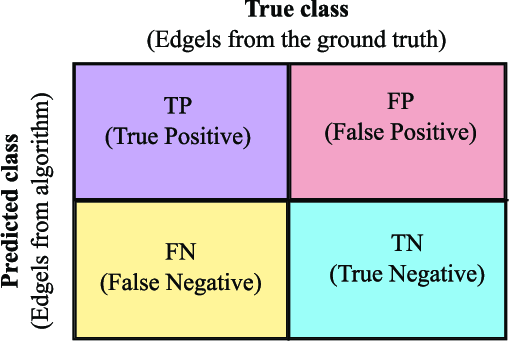

**Task** Compute accuracy based on confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

def accuracy(y, p):
    (TN, FP), (FN, TP) = confusion_matrix(y, p)
    return #your code here

In [ ]:
accuracy(y_example, y_example_pred)

There are other metrics:

* Precision is the fraction of correctly classified as class 1 among the all classified as class 1 objects (Idea: how precise is our prediction? How often we are correct about our 1 prediction?)

* Recall is the fraction of correctly classified as class 1 among the all class 1 objects (Idea: how much of the class 1 we can acutally detect?)

Precision and recall are from 0 to 1 (closer to 1 the better).

**Task** Compute precision and recall

In [ ]:
def precision(y, p):
    (TN, FP), (FN, TP) = confusion_matrix(y, p)

    return #your code here

def recall(y, p):
    (TN, FP), (FN, TP) = confusion_matrix(y, p)

    return #your code here

For our example, it is impossible to compute precision (bacause $TP = FP = 0$). It means that our prediction is very bad.

In [ ]:
precision(y_example, y_example_pred)

There is precision in sklearn library. If we cannot compute it, it will be 0

In [ ]:
from sklearn.metrics import precision_score

precision_score(y_example, y_example_pred)

Recall will be 0, because $TP = 0$

In [ ]:
recall(y_example, y_example_pred)

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_example, y_example_pred)

However, the metrics are one-sided: if we classify everything with class 1 we will get ideal recall

In [ ]:
recall(y_example, np.ones(len(y_example))), precision(y_example, np.ones(len(y_example)))

We can combine them using F-score = $(2\times precision \times recall)/ (precision + recall)$

**Task** Compute F1-score

In [ ]:
def f1(y, p):
    #your code here

In [ ]:
f1(y_example, y_example_pred)

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_example, y_example_pred)

Let's compute metrics for our classifiers:

In [ ]:
metric_dict = {"Accuracy": accuracy,
               "Precision": precision,
               "Recall": recall,
               "F1-score": f1}

for title, func in metric_dict.items():
    print(title, func(y_test,  clf.predict(X_test)))


Let's search for hyperparameters again, now assess models with F1-score

In [ ]:
clf = GridSearchCV(LogisticRegression(), params,
                   cv=5, scoring='f1'
                   )
clf.fit(X_train, y_train)


for title, func in metric_dict.items():
    print(title, func(y_test,  clf.predict(X_test)))

The results seems to be setter

How can we improve the model:



*   Feature engineering (f.e. add polynominal features)
*   Try other models
*   [Not always possible] Add more features


The task is hard right now because we chose only 2 features, let's use all 4 features.

In [ ]:
X = pd.DataFrame(data['data'], columns = data['feature_names'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)


clf = GridSearchCV(LogisticRegression(), params,
                   cv=5, scoring='f1'
                   )
clf.fit(X_train, y_train)


for title, func in metric_dict.items():
    print(title, func(y_test,  clf.predict(X_test)))

## Multiclass classification with logistic regression

The results still are not good. We had 3 classes, but decided to ease the task and solved binary classification problem. Let's try to solve initial classification into 3 classes task

In [ ]:
#Let's make X 2D again
X = pd.DataFrame(data['data'], columns = data['feature_names'])[['sepal length (cm)', 'sepal width (cm)']]
y = data['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

Approach to multiclass: one-vs-rest (one-vs-all) strategy: train separate model to separate every class. ($K$ classes $⇒$ $K$ models)

In [ ]:
y_train

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

plot_decision_regions(X_train.values, y_train, clf=lr)

In [ ]:
print(accuracy_score(y_test,  lr.predict(X_test))) # the classes are balanced, may use accuracy

The default logistic regression now gives good result.

In [ ]:
lr.predict_proba(X_test)[:10]

Last experiment with logistic regression. Let's solve task with initial data (4 featrues) and search for hyperparameters

In [ ]:
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

clf = GridSearchCV(LogisticRegression(), params,
                   cv=5, scoring='accuracy'
                   )
clf.fit(X_train, y_train)

In [ ]:
print(accuracy_score(y_test,  clf.predict(X_test)))

Now it is good!

## Decision trees

![](https://drive.google.com/uc?id=13kmqLXa-3FBUJq0Q3XVOkz8TENpVTkqk)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


from mlxtend.plotting import plot_decision_regions

Let's try to use a decison tree for our multiclass iris data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

print(accuracy_score(y_test,  dt.predict(X_test)))

We achieved the same accuracy as with logistic regression without tuning hyperparameters.

Let's try tuning them. [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) in sklearn

In [ ]:
dt_params = {'criterion':['gini', 'entropy'],
             'max_depth' : [1, 2, 5, 10, None],
             'min_samples_split' : [2, 5, 10],
             'min_samples_leaf' : [1, 2, 5, 10]
             }

clf = GridSearchCV(DecisionTreeClassifier(), dt_params,
                   cv=5, scoring='accuracy',
                   verbose=5
                   )
clf.fit(X_train, y_train)

In [ ]:
clf.best_params_

More complicated model $→$ more hyperparameters, longer training

In [ ]:
print(accuracy_score(y_test,  clf.predict(X_test)))

Why no increase in quality?

**Task** Compute, how many objects are classified incorrectly

In [ ]:
#your code here

Even very good model may make some mistakes:



*   Outliers (particular flower is really different from the rest)
*   Errors (the flower was incorectly classified by a human)
*   Hard decision (the flower seems like several classes and the model cannot decide)



### Decision trees vs linear models

Decision tree is a new cool model, will it work better than liner regression?

In [ ]:
np.random.seed(13)
n = 500
X = np.zeros(shape=(n, 2))
X[:, 0] = np.linspace(-5, 5, 500)
X[:, 1] = X[:, 0] + 0.5 * np.random.normal(size=n)
y = (X[:, 1] > X[:, 0]).astype(int)
plt.scatter(X[:, 0], X[:, 1], s=100, c=y);

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=13
)

lr = LogisticRegression(random_state=13)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Linear model accuracy: {accuracy_score(y_pred_lr, y_test):.2f}")

Cool, what about a decision tree?

In [ ]:
dt = DecisionTreeClassifier(random_state=13)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Decision tree accuracy: {accuracy_score(y_pred_dt, y_test):.2f}")

Worse, let's plot and see the difference

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plot_decision_regions(X_test, y_test, lr)

plt.subplot(1, 2, 2)
plot_decision_regions(X_test, y_test, dt);

The data may be separated by a strainght line - logistic regression works fine.

The line is not horizontal/vertical - so tree has some complication.

Let's check another synthetic data:

In [ ]:
np.random.seed(13)
X = np.random.randn(500, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)
plt.scatter(X[:, 0], X[:, 1], s=100, c=y);

**Task** Divide data into train and test, fit Logistic regression and decision tree, compute accuracy and plot them. Compare the models, which works better, why?

In [ ]:
#your code here

**Conclusion:** best model depends on data.

### Overfitting

Again, some synthetic data. This data is harder, because there is a significant overlap of classes.

In [ ]:
np.random.seed(13)
n = 100
X = np.random.normal(size=(n, 2))
X[:50, :] += 0.25
X[50:, :] -= 0.25
y = np.array([1] * 50 + [0] * 50)
plt.scatter(X[:, 0], X[:, 1], s=100, c=y);

If there are no contradicting data (same features, different target), we can achieve the best possible quality of model on train data (accuracy=1, MSE=0)

In [ ]:
dt = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=13)
dt.fit(X, y)

print(f"Decision tree accuracy: {accuracy_score(y, dt.predict(X)):.2f}")

plot_decision_regions(X, y, dt);

Let's investigatre, how the model changes if we change hyperparameters

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i, max_depth in enumerate([3, 5, None]):
    for j, min_samples_leaf in enumerate([15, 5, 1]):
        dt = DecisionTreeClassifier(
            max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=13
        )
        dt.fit(X, y)
        ax[i][j].set_title(
            "max_depth = {} | min_samples_leaf = {}".format(max_depth, min_samples_leaf)
        )
        ax[i][j].axis("off")
        plot_decision_regions(X, y, dt, ax=ax[i][j])

plt.show()

### Instability

Let's conduct an experiment: we will use random 90\% of our data and fit the decision tree. Will it change a lot?

**Task** Choose 90\% random samples

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i in range(3):
    for j in range(3):
        seed_idx = 3 * i + j
        np.random.seed(seed_idx)
        dt = DecisionTreeClassifier(random_state=13)

        #Create X_part, y_part - parts of the initial sample X, y
        #May use np.random.choice to sample indices
        #your code here

        dt.fit(X_part, y_part)
        ax[i][j].set_title("sample #{}".format(seed_idx))
        ax[i][j].axis("off")
        plot_decision_regions(X_part, y_part, dt, ax=ax[i][j])

plt.show()

The plot changes a lot, let's also check if logistic regression changes a lot, too:

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i in range(3):
    for j in range(3):
        seed_idx = 3 * i + j
        np.random.seed(seed_idx)
        dt = LogisticRegression(random_state=13)

        #Create X_part, y_part - parts of the initial sample X, y
        #May use np.random.choice to sample indices
        #your code here

        dt.fit(X_part, y_part)
        ax[i][j].set_title("sample #{}".format(seed_idx))
        ax[i][j].axis("off")
        plot_decision_regions(X_part, y_part, dt, ax=ax[i][j])

plt.show()

### Visualization

In [ ]:
from sklearn.tree import plot_tree

plot_tree(clf.best_estimator_, filled=True, rounded=True, feature_names=X_train.columns);

### Decision tree for regression

Dataset of house prices in California

In [ ]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
california_X = pd.DataFrame(data=california.data, columns=california.feature_names)
california_Y = california.target
print(f"X shape: {california_X.shape}, Y shape: {california_Y.shape}")
california_X.head()

In [ ]:
plt.title("House price distribution")
plt.xlabel("price")
plt.ylabel("# samples")
plt.hist(california_Y, bins=20)
plt.show()

[DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) has similar hyperparameters, but the criterion is not Gini/entropy, but MSE

In [ ]:
from sklearn.tree import DecisionTreeRegressor

X_train, X_test, y_train, y_test = train_test_split(
    california_X, california_Y, test_size=0.25, random_state=13
)

dt = DecisionTreeRegressor(max_depth=3, random_state=13)
dt.fit(X_train, y_train)

plt.figure(figsize=(10,10))
plot_tree(dt, feature_names=california_X.columns, filled=True, rounded=True)
plt.show()

Let's check how the result depend on the max depth of the tree

In [ ]:
X_train.shape #May build deep trees

**Task** Fit a tree with every depth in `max_depth_array` array, compute and save MSE

In [ ]:
from sklearn.metrics import mean_squared_error
max_depth_array = range(2, 20)
mse_array = []

for max_depth in max_depth_array:
    #your code here

plt.plot(max_depth_array, mse_array)
plt.title("Dependence of MSE on max depth")
plt.xlabel("max depth")
plt.ylabel("MSE");

**Task** Choose the depth with the best MSE

In [ ]:
#your code here

**Task** Conduct same experiment with `min_samples_leaf`, use the best depth

In [ ]:
min_samples_leaf_array = range(1, 20)
mse_array = []

for min_samples_leaf in min_samples_leaf_array:
    #your code here

plt.plot(min_samples_leaf_array, mse_array)
plt.title("Dependence of MSE on min samples leaf")
plt.xlabel("min samples leaf")
plt.ylabel("MSE");

**Task** Choose the min samples leaf with the best MSE and fit the model again

In [ ]:
#your code here

In [ ]:
dt = DecisionTreeRegressor(max_depth=#your code here,
                           min_samples_leaf=#your code here,
                           random_state=13)
dt.fit(X_train, y_train)

mean_squared_error(y_test, dt.predict(X_test))

Let's use grid search to tune hyperparameters (Note: in the previous example we used test data to choose the best model, in reality we will use validation set)

It may take 2-5 minutes

In [ ]:
dt_params = {
             'max_depth' : max_depth_array,
             'min_samples_leaf' : min_samples_leaf_array
             }

clf = GridSearchCV(DecisionTreeRegressor(), dt_params,
                   cv=3,
                   scoring='neg_root_mean_squared_error', #scoring for regression
                   verbose=5
                   )
clf.fit(X_train, y_train)
mean_squared_error(y_test, clf.predict(X_test))

In [ ]:
clf.best_params_

The result is better and the hyperparameters are different.

It is possible to measure feature importance (for classification and regression) - sklearn computes them for us.

In [ ]:
pd.DataFrame(
    {"feature": california_X.columns, "importance": clf.best_estimator_.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

**Question** does scaling change anything?

**Task** Apply scaling and fit the model with same hyperparameters - what is different? (Feature importances? Error?)

In [ ]:
from sklearn.preprocessing import StandardScaler

#Apply scaling
#your code here

sc = StandardScaler()
X_train_scaled = pd.DataFrame(
    sc.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    sc.transform(X_test), columns=X_test.columns, index=X_test.index
)
X_train_scaled.head()

dt1 = DecisionTreeRegressor(random_state=13,
                            #your code here
                            )
#Fit model, compute MSE, depict importances
#your code here

## Ensembles

### First ensemble

Data similar from the data from the lecture

In [ ]:
np.random.seed(0)

cloud1 = np.random.multivariate_normal(mean=[  0.0, 0.0], cov=[[1.0, 0.0], [0.0, 0.5]], size=50)
cloud2 = np.random.multivariate_normal(mean=[-15.0, 0.0], cov=[[1.0, 0.0], [0.0, 0.5]], size=50)
cloud3 = np.random.multivariate_normal(mean=[ 15.0, 0.0], cov=[[1.0, 0.0], [0.0, 0.5]], size=50)


data = np.concatenate([cloud1, cloud2, cloud3])
data.shape

Target (class)

In [ ]:
y = -np.ones(len(data), dtype='int32')
y[:50] = 1

In [ ]:
y

Let's draw a scatterplot

In [ ]:
plt.scatter(data[:,0], data[:,1],c=y)

#Setting limits for x2
plt.ylim([-6, 6])

The data is not linearly separated - impossible to draw a straight line and separate yellow class from purple

Let's try to build a model, similar from the one from the lecture

Model 1

Let's try to separate right cloud from the middle and left one using linear model:

if $x_1w_1 + w_2x_2 + w_0 > 0$ - class 1

if $x_1w_1 + w_2x_2 + w_0 < 0$ - class -1

**Task** Find weights to find the correct model

In [ ]:
w_0 = 0 #your code here
w_1 = 1 #your code here
w_2 = 1 #your code here


x_1 = np.arange(data[:,0].min(), data[:,0].max()+0.2, 0.05)
x_2_model_1 = -(w_0 + x_1 * w_1) / w_2
plt.plot(x_1, x_2_model_1, label='Model 1')


plt.scatter(data[:,0], data[:,1],c=y)
plt.ylim([-6, 6])
plt.legend()

Let's check quality:

In [ ]:
linear_combination1 = w_1 * data[:,0] + w_2 * data[:,1] + w_0
prediction1 = np.sign(linear_combination1).astype('int')

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y, prediction1)

The accuracy is not ideal. Let's check, if our model is better than classifierthat predicts the most popular class.

In [ ]:
#Looking at the classes in y and the number of samples
np.unique(y, return_counts=True)

In [ ]:
#-1 is the most popular class
#predicting always -1 and computing accuracy
accuracy_score(y, -np.ones(len(y)))

The accuracy is the same. So, our model was not so great.

Model 2

Now. let's conduct the same experiment with the left cloud (separate it from the rest)


if $x_1v_1 + v_2x_2 + v_0 > 0$ - class 1

if $x_1v_1 + v_2x_2 + v_0 < 0$ - class -1

In [ ]:
#Need to change weights to find the correct model
v_0 = 0
v_1 = 1
v_2 = 1

#generate x1
x_1 = np.arange(data[:,0].min(), data[:,0].max()+0.2, 0.05)
#calculate x2
x_2_model_2 = -(v_0 + x_1 * v_1) / v_2
plt.plot(x_1, x_2_model_2, label='Model 1')


plt.scatter(data[:,0], data[:,1],c=y)
plt.ylim([-6, 6])
plt.legend()

Let's use the model and measure accuracy:

In [ ]:
linear_combination2 = v_1 * data[:,0] + v_2 * data[:,1] + v_0
prediction2 = np.sign(linear_combination2).astype('int')
prediction2

In [ ]:
accuracy_score(y, prediction2)

We got same results

Now, let's understand, where the model make mistakes and how to correct them

In [ ]:
# sep - how the words should be separated
print('Target', 'Model 1', 'Model 2', sep='\t')

#Choosing every fifth element
for i in range(0, len(data), 5):
  print(y[i], prediction1[i], prediction2[i], sep='\t')

We can conclude:



*   If both models predict 1, we should predict 1
*   If models contradict, we should predict -1
*   Models do not predict -1 together

How can we get the best possible prediction based on the prediction of both models? - For example, we can multiply them (1 * 1 = 1, -1 * 1 = -1)



**Task** Merge models

In [ ]:
def ensemble_model_prediction(data):
  #Copy-paste the weights from the experiments
  #your code here

  #Model 1
  #your code here

  #Model 2
  #your code here

  #ensemble prediction
  prediction = #your code here

  return prediction

Let's test it

In [ ]:
prediction = ensemble_model_prediction(data)
accuracy_score(y, prediction)

Now, the quality is ideal

We may want to depict regions using function, but we would need to add some code, because the function is designed to work with models that return 0/1 as predictions

In [ ]:
from mlxtend.plotting import plot_decision_regions

class SimpleEnsemble:
  def predict(self, X):
    return (1 + ensemble_model_prediction(X)) // 2
plot_decision_regions(data, y, SimpleEnsemble());

### Voting classifier

In previous task we could multiply predictions, but this is not a common tactic (most likely, it will not work another dataset).

What may work? - voting

Idea: build a lot of different classifiers (Logistic regression, decision tree, ...) and choose the most popular answer anong them

Let's work with Iris again

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


data = load_iris()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target'].copy()
y[y!=1] = 0



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

In [ ]:
X_train.shape

Let's build several classification models (see [sklearn documentation](https://scikit-learn.org/1.5/supervised_learning.html) to find out new classifiaction models)

All the model from sklearn has `fit` and `predict` methods, so it is easy to work with new models

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier


models = [
    LogisticRegression(),
    DecisionTreeClassifier(max_depth=1),
]

titles = ['Logistic Regression', 'Decision Tree']

#fit and test every model
for model, title in zip(models, titles):
  model.fit(X_train, y_train)
  print(accuracy_score(y_test, model.predict(X_test)), title)

Now, the models can be used for voting

There are 2 types of voting:


*   Hard voting - predict the class with majority of votes (if 3 classifier predicted class 1 and one will predict class 0, the result will be class 1)
*   Soft voting - probabilities, predicted by classifiears are used (if probabilities for class 1 were [0.8, 0.7, 0.9, 0.1] and for class 0 - [0.2, 0.3, 0.1, 0.9], the probability for class 1 will be 0.675, for class 0 = 0.375)



Hard voting:

In [ ]:
def hard_voting(predictions):
  #predictions - list of lists predictions from every model for the sample

  pred = []
  for prediction_sample in predictions:
    #for every class, we know how many models predicted it
    classes, votes = np.unique(prediction_sample, return_counts=True)

    pred.append(classes[votes.argmax()])
  return np.array(pred)

Example:

In [ ]:
hard_voting([[1, 1, 2, 1, 2, 3],
             [2, 2, 2, 2, 2, 2],
             [2, 1, 1, 1, 1, 3]])

Let's apply to our data

In [ ]:
predictions = np.array([model.predict(X_test) for model in models]).T

predictions.shape

In [ ]:
predictions_ensemble = hard_voting(predictions)

In [ ]:
predictions_ensemble.shape

In [ ]:
accuracy_score(y_test, predictions_ensemble)

We implemented the voting system ourselves, but we also can use the `VotingClassifier` from sklearn:

In [ ]:
from sklearn.ensemble import VotingClassifier

models_names = [
    ('Logistic Regression', LogisticRegression()),
    ('Decision Tree', DecisionTreeClassifier(max_depth=1))
]

#hard voting
voting = VotingClassifier(models_names,
                          voting='hard'
                          )

voting.fit(X_train, y_train)

accuracy_score(y_test, voting.predict(X_test))

Why voting did not help here?



In [ ]:
np.unique(predictions == y_test[:,None], axis=0, return_counts=True)

These models usually have same predicions - when voting the result is the same, and there are 4 samples with  which models disagree and voting takes one of the prediction (not based on anything) and does not help. Voting may help if there are more models, they are diverse enough.

Let's check regression

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Lasso, Ridge, LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    california_X, california_Y, test_size=0.25, random_state=13
)

models_names = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(alpha=0.01)),
    ('Lasso', Lasso(alpha=0.01)),
    ('Decision Tree', DecisionTreeRegressor(max_depth=17))
]

#fit and test every model
for title, model in models_names:
  model.fit(X_train, y_train)
  print(mean_squared_error(y_test, model.predict(X_test)), title)

voting = VotingRegressor(models_names)

voting.fit(X_train, y_train)

mean_squared_error(y_test, voting.predict(X_test))

MSE of voting is smaller than MSE of every model (to get better result we need to tune hyperparameters)

### Bagging + Random Forest

Idea: generate new samples from our using bootstrap (samples are close enough, so the models wil extract similar real dependencies, but different enough to overfitted models to differ)

Let's work with some bigger dataset for regression

Let's fit a decision tree

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)


print(f"MSE on train set: {mean_squared_error(y_train, tree.predict(X_train)):.2f}")
print(f"MSE on test set: {mean_squared_error(y_test, tree.predict(X_test)):.2f}")

MSE on train data is 0.0, but on test data is larger. That seems like overfitting. (Decision tree without constraints can reach ideal quality on non-contradicting data.

Let's try to use bagging. First of all, let's implement bootstrap.

Idea: from our data choose random elements and get new sample with the same number of samples

In [ ]:
def bootstrap(samples):
  idx = np.random.choice(len(samples), replace=True, size=len(samples))
  return samples[idx].copy()

In [ ]:
bootstrap(np.array([1,2,3,4,5]))

In [ ]:
def generate_bootstrap(samples, N):
  bootstrap_samples = []
  for i in range(N):
    bootstrap_samples.append(bootstrap(samples))
  return np.array(bootstrap_samples)

In [ ]:
generate_bootstrap(np.array([1,2,3,4,5]), 3)

Let's generate several bootstrap samples and investigate features.

In [ ]:
np.random.seed(0)
N = 8

#We need to merge X and y, because the same bootstrap should be applied to both X and y
X_y_train = X_train.copy()
X_y_train['y'] = y_train.copy()

bootstrap_samples = generate_bootstrap(X_y_train.values, N)
bootstrap_samples.shape

In [ ]:
fig, axs = plt.subplots(ncols=N//2, nrows=2, figsize=(20,10), sharex=True, sharey=True)

feature = 2
for i in range(N):
  axs[i//4][i%4].scatter(bootstrap_samples[i][:,feature], bootstrap_samples[i][:,-1])

fig.suptitle('Feature ' + X_y_train.columns[feature] + ' and target', fontsize=16)
plt.show();

Now, let's fit separate decision tree with every sample we have

In [ ]:
models = []

for sample in bootstrap_samples:
  tree = DecisionTreeRegressor(random_state=0)
  tree.fit(sample[:,:-1], sample[:,-1])
  models.append(tree)

In [ ]:
models

How does every tree perform?

In [ ]:
for tree in models:
  print(f"MSE on test set: {mean_squared_error(y_test, tree.predict(X_test.values)):.3f}")

Now, let's take mean prediction for every sample

In [ ]:
preds_trees = []
for tree in models:
  preds_trees.append(tree.predict(X_test.values))
preds_trees = np.array(preds_trees)

preds_trees.shape

In [ ]:
mean_prediction = np.mean(preds_trees, axis=0)
mean_prediction.shape

In [ ]:
mean_prediction

In [ ]:
print(f"MSE on test set: {mean_squared_error(y_test, mean_prediction):.2f}")

The MSE on test  decreased! The bagging seems to be working

Let's now use the `BaggingRegressor` from sklearn. It will perform bootstrap, fit several models and take mean as prediction

In [ ]:
from sklearn.ensemble import BaggingRegressor

base_tree = DecisionTreeRegressor(random_state=0)

#we will have 8 trees
bag = BaggingRegressor(base_tree,
                       n_estimators=8
                       )
bag.fit(X_train, y_train)


print(f"MSE on train set: {mean_squared_error(y_train, bag.predict(X_train)):.2f}")
print(f"MSE on test set: {mean_squared_error(y_test, bag.predict(X_test)):.2f}")

MSE on train set increases, because not every tree is fitted to predict every sample, so particular overfitted trees may be wrong on train data. MSE on test set is better.

How many models should we take?

Let's fit bagging several times with different number of models

In [ ]:
n_trees = range(1, 52, 5)
train_loss = []
test_loss = []

for i in n_trees:
    print(i)
    bagging = BaggingRegressor(base_tree,
                               n_estimators=i,
                               n_jobs=4

                       )
    bagging.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, bagging.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, bagging.predict(X_test)))

plt.figure(figsize=(10, 7))
plt.title("Dependency of MSE and number of models for Bagging")
plt.grid()
plt.plot(n_trees, train_loss, label="MSE_train")
plt.plot(n_trees, test_loss, label="MSE_test")
plt.ylabel("MSE")
plt.xlabel("Number of models")
plt.legend();

When we had only 1 tree - MSE was big, we started adding trees and the error begin decreasing. However, after having ~20 trees it stopped decreasing and became almost constant.

Why? in the beginning every new tree brings useful information, new predictions, but after we added a lot of trees, next one will not be useful, it will be repeating the answers of previous one and the impact will be smaller.

### Random Forest

Bagging can be used with any base model (linear regression, decision tree).

Using trees is the most popular variant (they can learn non-linear dependencies, but easily overfit). It is possible to apply additional modification to make trees mode diverse - limit the number of features that can be used while spliting nodes in trees. Trees will still be able to discover complex dependencies, but they will significantly differ from each

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=8, n_jobs=4, max_features=0.5)
rf.fit(X_train, y_train)

print(f"MSE on train set: {mean_squared_error(y_train, rf.predict(X_train)):.4f}")
print(f"MSE on train set: {mean_squared_error(y_test, rf.predict(X_test)):.4f}")

In [ ]:
rf.max_features

The results are similar to the ones of bagging. Let's investigate number of trees:

In [ ]:
n_trees = range(1, 52, 5)
train_loss = []
test_loss = []

for i in n_trees:
    print(i)
    rf = RandomForestRegressor(n_estimators=i, n_jobs=4, max_features=0.5)
    rf.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, rf.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 7))
plt.title("Dependency of MSE and number of trees for Random Forest")
plt.grid()
plt.plot(n_trees, train_loss, label="MSE_train")
plt.plot(n_trees, test_loss, label="MSE_test")
plt.ylabel("MSE")
plt.xlabel("Number of trees")
plt.legend();

### Boosting

Idea: we fitted one model and it made some mistekes, let's teach the next model to fix them.

Example: the item costed 15 rub., model 1 predicted that the item will cost 25rub.. So the  model 2 should try to predict 15rub. - 25rub. = -10rub..

Predictions of model 2 cannot be used without predictions of model 1 (item cannot cost -10rub.), so, we will need to sum the predictions to get the final prediction: 25rub. + (-10rub.) = 15rub.


$$a(x) = \sum_{n=1}^N b_n(x)$$

$a(x)$ - the prediction of the ensemble

$b_n(x)$ - the prediction of the $n$-th base model

Model 1 and 2 (base models) are usually trees, but significantly underfitted (not deep, not many leaves, a lot of samples in each leaf). That prevents the overfitting of boosting (if an overfitted model will be fixing the mistakes of overfitted model, the ensemble will be significantly overfitted)

Let's investigate this idea using synthetic data:

In [ ]:
#Generation of samples
np.random.seed(123)
N = 100
X = np.linspace(0, 1, N).reshape(-1, 1)
y = np.sin(X)[:, 0] + np.random.normal(0, 0.1, size=N)


#Function for visualization
def plot_sample_model(
    X, y, plot_predictions=False, y_pred=None, y_pred_label=None
):
    plt.figure(figsize=(10, 7))
    plt.scatter(X, y, label="Train", alpha=0.7)
    if plot_predictions:
        plt.plot(X, y_pred, label=y_pred_label, c="r")
        plt.title("MSE: " + str(mean_squared_error(y, y_pred)))

    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()


plot_sample_model(X, y, plot_predictions=False)

*Step 0.* At the beginnig, we have no base models, the ensemble is empty.

In [ ]:
#The prediction of the ensemble
a = 0

*Step 1* Let's fit first model $b_1(x)$. Let's use decision trees of depth 1 (decision stump)

In [ ]:
from sklearn.tree import DecisionTreeRegressor


b = DecisionTreeRegressor(max_depth=1).fit(X, y)


a = b.predict(X)


plot_sample_model(
    X, y, plot_predictions=True, y_pred=a, y_pred_label="a = b_1"
)

**Task** *Step 2*  Comute the mistakes (residuals) of the ensemble

In [ ]:
s = #your code here

*Step 3* Fit next model ($b_2(x)$). This model tries to predict the residuals. The ensemble will be $a(x) = b_1(x) + b_2(x)$

In [ ]:
b = DecisionTreeRegressor(max_depth=1).fit(X, s)

#Add the prediction of the model to the ensemble
a += b.predict(X)

plot_sample_model(
    X, y, plot_predictions=True, y_pred=a, y_pred_label="a = b_1 + b_2"
)

The MSE is better and the model is better

*Step 4 - ...* Repeat Steps 2,3 (compute residuals, fit next model, add the new predictions)

In [ ]:
s = #your code here

b = DecisionTreeRegressor(max_depth=1).fit(X, s)

#Add the prediction of the model to the ensemble
a += b.predict(X)

plot_sample_model(
    X, y, plot_predictions=True, y_pred=a, y_pred_label="a = b_1 + b_2 + b_3"
)

In [ ]:
s = #your code here
b = DecisionTreeRegressor(max_depth=1).fit(X, s)

#Add the prediction of the model to the ensemble
a += b.predict(X)

plot_sample_model(
    X, y, plot_predictions=True, y_pred=a, y_pred_label="a"
)

More steps - the more complex model, the more precise predictions on the train data.

And what will happened on test data? - Most likely, firstly the MSE will decrease (we will be fixing serious mistakes), but after a lot of models we will be overfitting (fixing minor mistakes on train data) and error on test will be increaing.

So, the boosting may overfit if we have a lot of models (random forest did not overfit)

Some boosting from sklearn - AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor


ada = AdaBoostRegressor(DecisionTreeRegressor(max_depth=1), n_estimators=20)
ada.fit(X, y)

plot_sample_model(
    X, y, plot_predictions=True, y_pred=ada.predict(X), y_pred_label="AdaBoost"
)

In [ ]:
ada = AdaBoostRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=20)
ada.fit(X_train, y_train)

mean_squared_error(y_test, ada.predict(X_test))